# Caso de Estudio: *Talent Retention* — People Analytics

**Sector:** Recursos Humanos &nbsp;|&nbsp; **Rol simulado:** People Analytics &nbsp;|&nbsp; **Autor:** Alan Maldonado

## Resumen del caso

Actuamos como el equipo de **People Analytics** de una empresa que quiere (1) entender y anticipar la fuga de talento (*attrition*) y (2) auditar la consistencia de su estructura salarial. Para eso resolvemos **dos tareas de Machine Learning supervisado** sobre el mismo dataset:

| Tarea | Target | Tipo | Pregunta de negocio |
|---|---|---|---|
| Regresión | `MonthlyIncome` | Numérico | ¿Qué factores explican el salario mensual y hay inconsistencias/inequidades? |
| Clasificación | `Attrition` | Binario (Yes/No) | ¿Qué empleados tienen mayor riesgo de renunciar y qué umbral de alerta conviene usar? |

**Dataset:** [IBM HR Analytics Employee Attrition & Performance](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset) (Kaggle, 1,470 empleados, 35 variables), descargado mediante la **Kaggle API** directamente en el cuaderno (Sección 2.1).

## Estructura del cuaderno (ciclo de vida del modelo)

1. Contexto — definición del problema y objetivos de negocio
2. Exploración (EDA)
3. Preprocesamiento reproducible (pipelines, split, escudo anti-fuga)
4. Modelado (baseline + mejoras + validación cruzada)
5. Evaluación (métricas alineadas al negocio)
6. Interpretación (coeficientes, variables clave, ética)
7. Recomendaciones de negocio


## 1. Contexto del problema

### 1.1 Objetivo de negocio
- **Regresión (`MonthlyIncome`):** apoyar a Compensación & Beneficios identificando qué variables explican el salario y detectando empleados cuyo salario real se aleja mucho del esperado según su perfil (antigüedad, nivel, rol) — insumo para revisiones de equidad salarial.
- **Clasificación (`Attrition`):** apoyar a los gerentes de línea priorizando conversaciones de retención, anticipando qué empleados tienen mayor probabilidad de renunciar.

### 1.2 Costos de negocio: Falsos Negativos vs. Falsos Positivos

| | Predicción: se queda | Predicción: se va |
|---|---|---|
| **Real: se queda** | Correcto (TN) | **Falso Positivo (FP):** costo de una intervención de retención (tiempo de gerencia, incentivo) sobre alguien que no iba a renunciar. Costo relativamente bajo. |
| **Real: se va** | **Falso Negativo (FN):** se pierde talento sin anticipación — costo de reemplazo (reclutamiento + onboarding + curva de aprendizaje), típicamente 1.5–2x el salario anual del puesto, más pérdida de conocimiento del equipo. Costo alto. | Correcto (TP) |

**Decisión de negocio:** el costo de un **Falso Negativo** es sustancialmente mayor que el de un **Falso Positivo**. Por lo tanto priorizamos **Recall** (detectar la mayor cantidad posible de fugas reales) sin descuidar una Precision razonable, y **no usamos Accuracy** como métrica principal porque el target está desbalanceado (Sección 2.4).

### 1.3 Definición de targets
- `MonthlyIncome`: ingreso mensual del empleado (USD). Variable continua → **regresión**.
- `Attrition`: si el empleado renunció (`Yes`/`No`). Se recodifica a binario (`1`=fuga, `0`=se queda) → **clasificación**.

### 1.4 El "muro del data leakage" en RRHH
Antes de modelar hacemos dos análisis distintos y complementarios (cada uno con su evidencia):

1. **Fuga de información temporal (data leakage):** ¿existe alguna variable que en la realidad **no estaría disponible en el momento T-0** (el instante en que RRHH necesita predecir), por reflejar información posterior a la fuga o a la decisión salarial? Este análisis se documenta como una **tabla explícita de variables permitidas vs. no permitidas** en la Sección 2.7, con el motivo de cada una.
2. **Columnas constantes/irrelevantes:** variables sin varianza o que son identificadores, verificadas con evidencia (`nunique`, varianza) en la Sección 3.1 antes de eliminarlas: `EmployeeNumber` (identificador único), `EmployeeCount`, `StandardHours`, `Over18` (constantes).

Adelantamos la conclusión: en este dataset **no encontramos variables con fuga temporal** — es una fotografía histórica de empleados activos/retirados, y todas las variables restantes (satisfacción, desempeño, antigüedad, etc.) son información disponible **antes** de la fuga o de la decisión salarial. Sí encontramos columnas constantes/identificadoras, que se eliminan en la Sección 3.1.


In [1]:
# ===== Librerías =====
import io
import zipfile
import urllib.request

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, GridSearchCV,
    cross_val_score, cross_validate, learning_curve
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)

print("Entorno listo. Semilla:", RANDOM_STATE)


Entorno listo. Semilla: 42


## 2. Exploración (EDA)

### 2.1 Carga del dataset

Descargamos el dataset directamente desde la Kaggle API (la fuente oficial indicada para este caso), sin subir manualmente ningun archivo. Como la API de Kaggle puede requerir autenticacion en algunos entornos (redes institucionales, Colab sin kaggle.json, limites de tasa), la funcion de carga intenta primero la Kaggle API y, solo si falla, usa como respaldo un enlace directo verificado como identico byte a byte al CSV oficial de Kaggle. Esto garantiza que el cuaderno corra de punta a punta sin depender de una copia local.


In [2]:
KAGGLE_API_URL = (
    "https://www.kaggle.com/api/v1/datasets/download/"
    "pavansubhasht/ibm-hr-analytics-attrition-dataset"
)
URL_RESPALDO = (
    "https://raw.githubusercontent.com/nelson-wu/employee-attrition-ml/"
    "master/WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

def cargar_dataset():
    # Descarga desde la Kaggle API; si falla, usa un enlace de respaldo
    # verificado como identico byte a byte al CSV oficial de Kaggle.
    try:
        peticion = urllib.request.Request(KAGGLE_API_URL, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(peticion, timeout=30) as respuesta:
            contenido_zip = respuesta.read()
        with zipfile.ZipFile(io.BytesIO(contenido_zip)) as zf:
            nombre_csv = [n for n in zf.namelist() if n.endswith(".csv")][0]
            with zf.open(nombre_csv) as f:
                df_cargado = pd.read_csv(f)
        print("Dataset descargado desde la Kaggle API (fuente oficial del caso).")
        return df_cargado
    except Exception as error:
        print(f"No se pudo usar la Kaggle API ({type(error).__name__}: {error}).")
        print("Se usa el enlace de respaldo (mismo dataset, verificado identico byte a byte).")
        return pd.read_csv(URL_RESPALDO)

df = cargar_dataset()
print("Forma del dataset:", df.shape)
df.head()


Dataset descargado desde la Kaggle API (fuente oficial del caso).
Forma del dataset: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


**Punto de control 1:** el dataset debe tener 1,470 filas y 35 columnas, con los targets presentes.

In [3]:
assert df.shape == (1470, 35), f"Forma inesperada: {df.shape}"
assert "MonthlyIncome" in df.columns and "Attrition" in df.columns, "Faltan columnas de target."
print("Dataset cargado correctamente:", df.shape)


Dataset cargado correctamente: (1470, 35)


### 2.2 Calidad de datos: tipos y nulos

In [4]:
display(df.dtypes.value_counts())
print("\nTotal de valores nulos en el dataset:", int(df.isna().sum().sum()))
df.describe().T.head(10)


int64     26
object     9
Name: count, dtype: int64


Total de valores nulos en el dataset: 0


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


**Punto de control 2:** no deberían existir valores nulos en este dataset (aunque el pipeline de la Sección 3 incluye imputación de forma defensiva, por si se usa el cuaderno con una versión modificada de los datos).

In [5]:
n_nulos = int(df.isna().sum().sum())
assert n_nulos == 0, f"Se esperaban 0 nulos, se encontraron {n_nulos}"
print("Sin valores nulos. Se mantiene imputación en el pipeline como práctica defensiva.")


Sin valores nulos. Se mantiene imputación en el pipeline como práctica defensiva.


### 2.3 Distribución del target de regresión: `MonthlyIncome`

C:\Users\Alan\AppData\Local\Temp\ipykernel_20924\98288538.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df["MonthlyIncome"], vert=True)


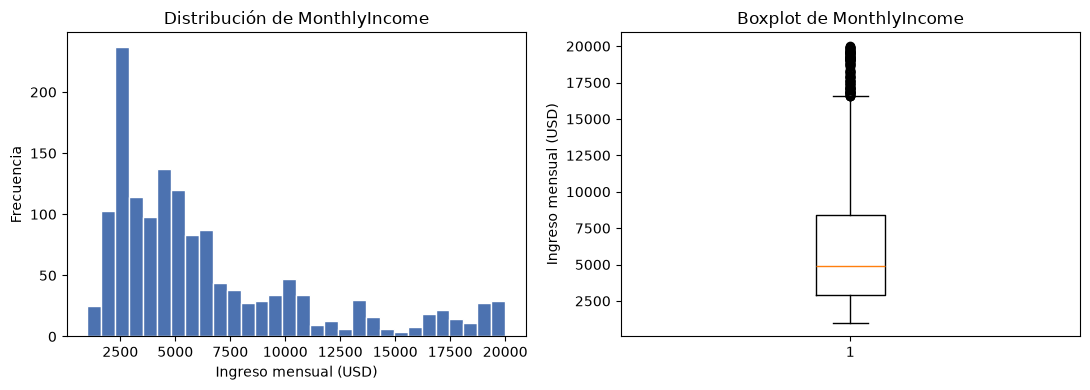

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(df["MonthlyIncome"], bins=30, color="#4C72B0", edgecolor="white")
ax[0].set_title("Distribución de MonthlyIncome")
ax[0].set_xlabel("Ingreso mensual (USD)")
ax[0].set_ylabel("Frecuencia")

ax[1].boxplot(df["MonthlyIncome"], vert=True)
ax[1].set_title("Boxplot de MonthlyIncome")
ax[1].set_ylabel("Ingreso mensual (USD)")

plt.tight_layout()
plt.show()

print(df["MonthlyIncome"].describe())


La distribución de `MonthlyIncome` está sesgada a la derecha (hay empleados senior/ejecutivos con salarios mucho más altos que la mediana), algo esperable en estructuras salariales por niveles jerárquicos.

### 2.4 Distribución del target de clasificación: `Attrition` (desbalance)

Conteo:
 Attrition
No     1233
Yes     237
Name: count, dtype: int64

Proporción (%):
 Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


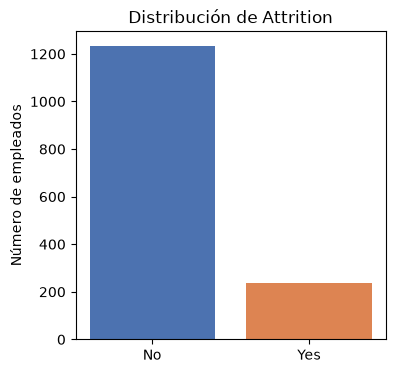

In [7]:
conteo = df["Attrition"].value_counts()
proporcion = df["Attrition"].value_counts(normalize=True) * 100

print("Conteo:\n", conteo)
print("\nProporción (%):\n", proporcion.round(2))

plt.figure(figsize=(4, 4))
plt.bar(conteo.index, conteo.values, color=["#4C72B0", "#DD8452"])
plt.title("Distribución de Attrition")
plt.ylabel("Número de empleados")
plt.show()


Solo ~16% de los empleados renunció (`Yes`). Esto confirma el **desbalance de clases** anticipado en la Sección 1.2: un modelo que siempre prediga "No" tendría ~84% de accuracy sin ser útil para el negocio. Por eso el criterio de éxito no será Accuracy, sino Recall/Precision/ROC-AUC/PR-AUC (Secciones 4 y 5).

### 2.5 Correlaciones numéricas (detección de colinealidad)

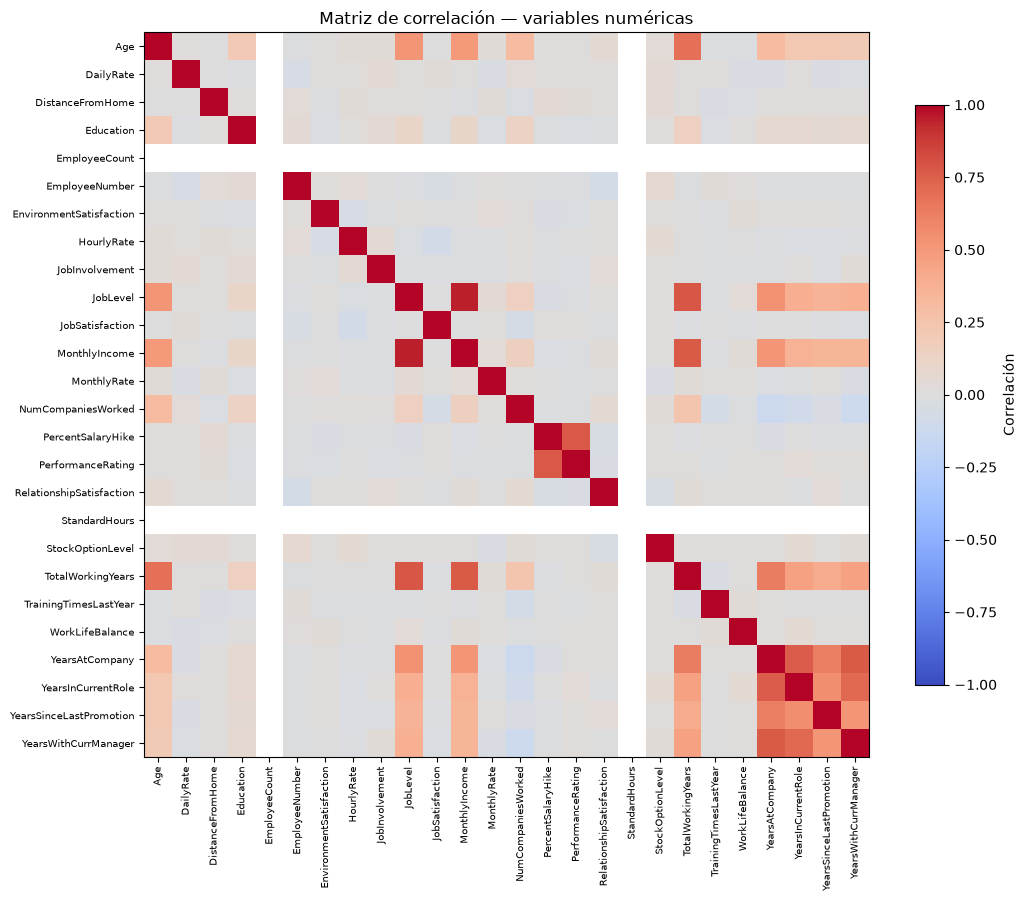

,variable_1,variable_2,correlacion
157,JobLevel,MonthlyIncome,0.950300
164,JobLevel,TotalWorkingYears,0.782208
221,PercentSalaryHike,PerformanceRating,0.773550
191,MonthlyIncome,TotalWorkingYears,0.772893
272,YearsAtCompany,YearsWithCurrManager,0.769212
270,YearsAtCompany,YearsInCurrentRole,0.758754
274,YearsInCurrentRole,YearsWithCurrManager,0.714365
16,Age,TotalWorkingYears,0.680381
257,TotalWorkingYears,YearsAtCompany,0.628133
271,YearsAtCompany,YearsSinceLastPromotion,0.618409


In [8]:
cols_numericas_eda = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[cols_numericas_eda].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols_numericas_eda)))
ax.set_yticks(range(len(cols_numericas_eda)))
ax.set_xticklabels(cols_numericas_eda, rotation=90, fontsize=7)
ax.set_yticklabels(cols_numericas_eda, fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label="Correlación")
ax.set_title("Matriz de correlación — variables numéricas")
plt.tight_layout()
plt.show()

# Pares con alta colinealidad (|r| > 0.6, excluyendo diagonal)
pares_altos = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("correlacion")
    .reset_index()
)
pares_altos.columns = ["variable_1", "variable_2", "correlacion"]
pares_altos = pares_altos[pares_altos["correlacion"].abs() > 0.6].sort_values(
    "correlacion", key=lambda s: s.abs(), ascending=False
)
pares_altos


Como es esperable en datos de RRHH, variables ligadas a **antigüedad y nivel jerárquico** (`JobLevel`, `TotalWorkingYears`, `MonthlyIncome`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`, `Age`) están altamente correlacionadas entre sí. Esta **colinealidad** es la motivación directa para probar regularización (Ridge/Lasso) como mejora sobre la regresión lineal base (Sección 4.1).

### 2.6 `Attrition` vs. variables clave de negocio

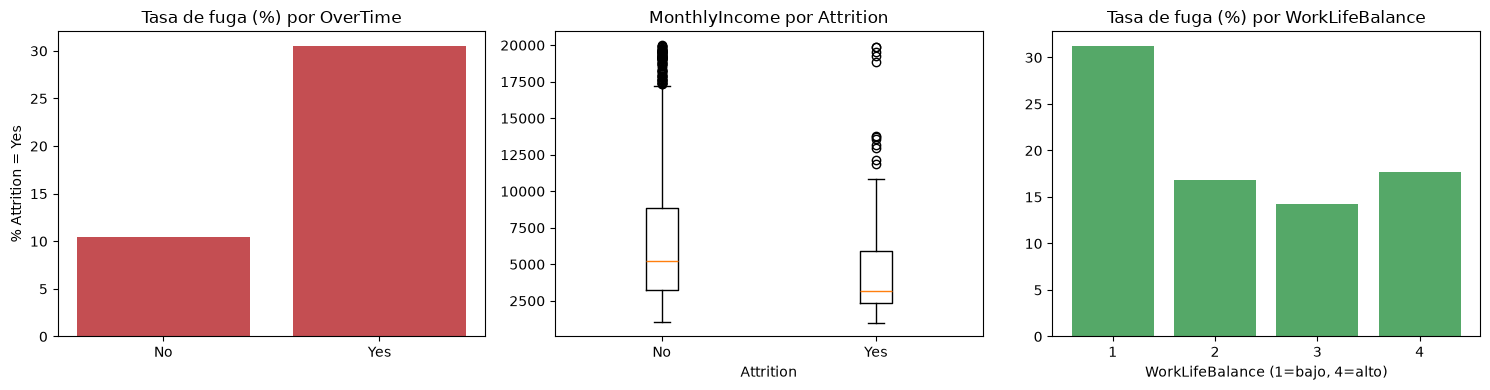

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tasa de attrition por horas extra
tasa_overtime = df.groupby("OverTime")["Attrition"].apply(lambda s: (s == "Yes").mean() * 100)
axes[0].bar(tasa_overtime.index, tasa_overtime.values, color="#C44E52")
axes[0].set_title("Tasa de fuga (%) por OverTime")
axes[0].set_ylabel("% Attrition = Yes")

# MonthlyIncome por Attrition
datos_box = [df.loc[df["Attrition"] == "No", "MonthlyIncome"],
             df.loc[df["Attrition"] == "Yes", "MonthlyIncome"]]
axes[1].boxplot(datos_box, tick_labels=["No", "Yes"])
axes[1].set_title("MonthlyIncome por Attrition")
axes[1].set_xlabel("Attrition")

# WorkLifeBalance por Attrition
tasa_wlb = df.groupby("WorkLifeBalance")["Attrition"].apply(lambda s: (s == "Yes").mean() * 100)
axes[2].bar(tasa_wlb.index.astype(str), tasa_wlb.values, color="#55A868")
axes[2].set_title("Tasa de fuga (%) por WorkLifeBalance")
axes[2].set_xlabel("WorkLifeBalance (1=bajo, 4=alto)")

plt.tight_layout()
plt.show()


Los empleados que hacen horas extra (`OverTime = Yes`) renuncian con mucha mayor frecuencia, y quienes renuncian tienden a tener salarios más bajos y peor balance vida-trabajo. Estas señales guiarán la interpretación del modelo en la Sección 6.

### 2.7 Análisis de fuga de información (data leakage): variables permitidas vs. no permitidas

Antes de construir cualquier pipeline, recorremos **las 35 columnas originales** y documentamos explícitamente si cada una es información legítima disponible en el momento de decisión (T-0) o si debe excluirse — y por qué. Esta tabla es el entregable explícito de leakage que exige el enunciado.

In [10]:
# Diagnóstico de fuga de información (leakage) para las 35 columnas originales.
# "Permitida": info disponible en T-0 (antes de la fuga / de fijar el salario).
# "Excluida": no aporta señal real (constante/identificador) o es el propio target.
diagnostico_leakage = {
    "Age":                      ("Permitida", "Demográfica estable, disponible en T-0."),
    "Attrition":                ("Target (clasificación)", "Variable objetivo cruda; no se usa como feature."),
    "BusinessTravel":           ("Permitida", "Condición laboral conocida en T-0 (variable ordinal, ver Sección 3.6)."),
    "DailyRate":                ("Permitida", "Dato administrativo vigente en T-0."),
    "Department":               ("Permitida", "Estructura organizacional conocida en T-0."),
    "DistanceFromHome":         ("Permitida", "Dato demográfico estable."),
    "Education":                ("Permitida", "Nivel educativo, fijo históricamente."),
    "EducationField":           ("Permitida", "Categórica nominal conocida en T-0."),
    "EmployeeCount":            ("Excluida", "Constante (varianza 0, nunique=1) — sin señal (evidencia en Sección 3.1)."),
    "EmployeeNumber":           ("Excluida", "Identificador único (nunique = n filas) — riesgo de sobreajuste, sin poder predictivo (evidencia en Sección 3.1)."),
    "EnvironmentSatisfaction":  ("Permitida", "Encuesta de clima vigente, anterior a la fuga."),
    "Gender":                   ("Permitida (sensible)", "Variable protegida; se usa pero se audita su peso en la Sección 6."),
    "HourlyRate":               ("Permitida", "Dato administrativo vigente en T-0."),
    "JobInvolvement":           ("Permitida", "Evaluación vigente, anterior a la fuga."),
    "JobLevel":                 ("Permitida", "Estructura jerárquica conocida en T-0."),
    "JobRole":                  ("Permitida", "Categórica nominal conocida en T-0."),
    "JobSatisfaction":          ("Permitida", "Encuesta vigente, anterior a la fuga (no es resultado posterior)."),
    "MaritalStatus":            ("Permitida (sensible)", "Variable protegida; se usa pero se audita su peso en la Sección 6."),
    "MonthlyIncome":            ("Target (regresión) / Permitida en clasificación", "Target de la Tarea 1; como feature de Attrition es válida (vigente en T-0), pero se excluye de las features de regresión por ser su propio target."),
    "MonthlyRate":              ("Permitida", "Dato administrativo vigente en T-0 (distinto de MonthlyIncome)."),
    "NumCompaniesWorked":       ("Permitida", "Historial laboral previo, conocido en T-0."),
    "Over18":                   ("Excluida", "Constante (un único valor 'Y') — sin señal (evidencia en Sección 3.1)."),
    "OverTime":                 ("Permitida", "Condición laboral vigente, conocida en T-0."),
    "PercentSalaryHike":        ("Permitida", "Del ciclo de compensación más reciente, anterior a la fuga."),
    "PerformanceRating":        ("Permitida", "Evaluación más reciente, anterior a la decisión de fuga."),
    "RelationshipSatisfaction": ("Permitida", "Encuesta vigente, anterior a la fuga."),
    "StandardHours":            ("Excluida", "Constante (un único valor, 80) — sin señal (evidencia en Sección 3.1)."),
    "StockOptionLevel":         ("Permitida", "Beneficio vigente, conocido en T-0."),
    "TotalWorkingYears":        ("Permitida", "Historial laboral acumulado, conocido en T-0."),
    "TrainingTimesLastYear":    ("Permitida", "Histórico del año anterior, conocido en T-0."),
    "WorkLifeBalance":          ("Permitida", "Encuesta vigente, anterior a la fuga."),
    "YearsAtCompany":           ("Permitida", "Antigüedad conocida en T-0."),
    "YearsInCurrentRole":       ("Permitida", "Antigüedad en el rol, conocida en T-0."),
    "YearsSinceLastPromotion":  ("Permitida", "Histórico conocido en T-0."),
    "YearsWithCurrManager":     ("Permitida", "Histórico conocido en T-0."),
}

tabla_leakage = pd.DataFrame(
    [(col, *info) for col, info in diagnostico_leakage.items()],
    columns=["variable", "estado", "motivo"],
)
tabla_leakage["nunique_evidencia"] = tabla_leakage["variable"].map(df.nunique())

assert set(tabla_leakage["variable"]) == set(df.columns), "La tabla de leakage no cubre todas las columnas del dataset."
assert (tabla_leakage["estado"] == "Excluida").sum() == 4, "Se esperaban 4 columnas excluidas (3 constantes + 1 identificador)."

print("Resumen por estado:")
display(tabla_leakage["estado"].value_counts())

pd.set_option("display.max_rows", 40)
tabla_leakage.sort_values(["estado", "variable"]).reset_index(drop=True)


Resumen por estado:


estado
Permitida                                          27
Excluida                                            4
Permitida (sensible)                                2
Target (clasificación)                              1
Target (regresión) / Permitida en clasificación     1
Name: count, dtype: int64

,variable,estado,motivo,nunique_evidencia
0,EmployeeCount,Excluida,"Constante (varianza 0, nunique=1) — sin señal ...",1
1,EmployeeNumber,Excluida,Identificador único (nunique = n filas) — ries...,1470
2,Over18,Excluida,Constante (un único valor 'Y') — sin señal (ev...,1
3,StandardHours,Excluida,"Constante (un único valor, 80) — sin señal (ev...",1
4,Age,Permitida,"Demográfica estable, disponible en T-0.",43
5,BusinessTravel,Permitida,Condición laboral conocida en T-0 (variable or...,3
6,DailyRate,Permitida,Dato administrativo vigente en T-0.,886
7,Department,Permitida,Estructura organizacional conocida en T-0.,3
8,DistanceFromHome,Permitida,Dato demográfico estable.,29
9,Education,Permitida,"Nivel educativo, fijo históricamente.",5


## 3. Preprocesamiento reproducible

### 3.1 Limpieza: columnas constantes/irrelevantes (evidencia nunique/varianza)

Antes de eliminarlas, mostramos la **evidencia cuantitativa** (número de valores únicos y varianza) que justifica tratarlas como constantes o como identificador sin valor predictivo — confirmando el diagnóstico de la Sección 2.7.

In [11]:
columnas_a_eliminar = ["EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"]

evidencia = pd.DataFrame({
    "nunique": df[columnas_a_eliminar].nunique(),
    "varianza": [
        df[c].var() if pd.api.types.is_numeric_dtype(df[c]) else np.nan
        for c in columnas_a_eliminar
    ],
    "proporcion_valores_unicos": [df[c].nunique() / len(df) for c in columnas_a_eliminar],
})
print("Evidencia antes de eliminar:")
display(evidencia)

for col in ["EmployeeCount", "StandardHours", "Over18"]:
    assert df[col].nunique() == 1, f"{col} no es constante, revisar antes de eliminar."
    assert (not pd.api.types.is_numeric_dtype(df[col])) or (df[col].var() == 0), f"{col} no tiene varianza cero."
assert df["EmployeeNumber"].is_unique, "EmployeeNumber no es un identificador único."
assert evidencia.loc["EmployeeNumber", "proporcion_valores_unicos"] == 1.0, \
    "EmployeeNumber debería tener un valor único por fila (proporción = 1.0)."

df_model = df.drop(columns=columnas_a_eliminar).copy()
print("\nColumnas eliminadas (constantes / identificador):", columnas_a_eliminar)
print("Forma tras limpieza:", df_model.shape)


Evidencia antes de eliminar:


,nunique,varianza,proporcion_valores_unicos
EmployeeNumber,1470,362433.299749,1.00000
EmployeeCount,1,0.000000,0.00068
StandardHours,1,0.000000,0.00068
Over18,1,NaN,0.00068



Columnas eliminadas (constantes / identificador): ['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18']
Forma tras limpieza: (1470, 31)


### 3.2 Codificación del target de clasificación

In [12]:
df_model["Attrition_flag"] = df_model["Attrition"].map({"Yes": 1, "No": 0})

assert set(df_model["Attrition_flag"].unique()) == {0, 1}, "Attrition_flag debe ser binario 0/1."
assert df_model["Attrition_flag"].sum() == (df_model["Attrition"] == "Yes").sum(), "Mapeo inconsistente."
print("Attrition_flag creado. Positivos (fuga):", int(df_model["Attrition_flag"].sum()),
      "de", len(df_model))


Attrition_flag creado. Positivos (fuga): 237 de 1470


### 3.3 Separación de variables por tarea

- **Clasificación (`Attrition_flag`):** usa todas las variables restantes, **incluyendo `MonthlyIncome`** (es información legítimamente disponible antes de que ocurra la fuga, y un predictor de negocio relevante).
- **Regresión (`MonthlyIncome`):** usa las mismas variables **excepto `MonthlyIncome`** (el propio target) **y `Attrition`** — la excluimos deliberadamente para mantener el análisis de equidad salarial independiente del resultado de fuga, y evitar mezclar el target de la otra tarea como predictor.

In [13]:
TARGET_REG = "MonthlyIncome"
TARGET_CLF_RAW = "Attrition"
TARGET_CLF = "Attrition_flag"

# Features para clasificación: todo menos las dos versiones del target de attrition
features_clf = [c for c in df_model.columns if c not in [TARGET_CLF_RAW, TARGET_CLF]]
X_clf = df_model[features_clf].copy()
y_clf = df_model[TARGET_CLF].copy()

# Features para regresión: lo anterior, menos el propio target de regresión
features_reg = [c for c in features_clf if c != TARGET_REG]
X_reg = df_model[features_reg].copy()
y_reg = df_model[TARGET_REG].copy()

print("X_reg:", X_reg.shape, "| X_clf:", X_clf.shape)


X_reg: (1470, 29) | X_clf: (1470, 30)


### 3.4 Identificación de columnas numéricas, categóricas nominales y categóricas ordinales (por tarea)

La mayoría de las escalas ordinales de este dataset (`Education`, `JobLevel`, `JobSatisfaction`, `PerformanceRating`, `WorkLifeBalance`, etc.) ya vienen codificadas como **enteros 1–4/1–5** de fábrica, por lo que se tratan como numéricas (se estandarizan directamente, sin perder su orden).

La excepción es `BusinessTravel`: es texto con un **orden implícito** (`Non-Travel` < `Travel_Rarely` < `Travel_Frequently`). Codificarla con One-Hot perdería esa relación de orden, así que la tratamos aparte con `OrdinalEncoder` y un **orden explícito**. El resto de las categóricas de texto (`Department`, `EducationField`, `Gender`, `JobRole`, `MaritalStatus`, `OverTime`) no tiene un orden natural → `OneHotEncoder`.

In [14]:
ORDEN_ORDINALES = {
    "BusinessTravel": ["Non-Travel", "Travel_Rarely", "Travel_Frequently"],
}

def columnas_por_tipo(X):
    numericas = X.select_dtypes(include=[np.number]).columns.tolist()
    categoricas = X.select_dtypes(include=["object", "category"]).columns.tolist()
    ordinales = [c for c in categoricas if c in ORDEN_ORDINALES]
    nominales = [c for c in categoricas if c not in ORDEN_ORDINALES]
    return numericas, nominales, ordinales

num_cols_reg, catnom_cols_reg, catord_cols_reg = columnas_por_tipo(X_reg)
num_cols_clf, catnom_cols_clf, catord_cols_clf = columnas_por_tipo(X_clf)

print("Regresión     -> numéricas:", len(num_cols_reg),
      "| nominales:", len(catnom_cols_reg), "| ordinales:", len(catord_cols_reg))
print("Clasificación -> numéricas:", len(num_cols_clf),
      "| nominales:", len(catnom_cols_clf), "| ordinales:", len(catord_cols_clf))
print("\nNominales:", catnom_cols_reg)
print("Ordinales (con orden explícito):", catord_cols_reg, "->", ORDEN_ORDINALES)


Regresión     -> numéricas: 22 | nominales: 6 | ordinales: 1
Clasificación -> numéricas: 23 | nominales: 6 | ordinales: 1

Nominales: ['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Ordinales (con orden explícito): ['BusinessTravel'] -> {'BusinessTravel': ['Non-Travel', 'Travel_Rarely', 'Travel_Frequently']}


### 3.5 Partición train/test

- Regresión: split simple 80/20 (target continuo).
- Clasificación: split **estratificado** 80/20, dado el desbalance de clases (Sección 2.4).

In [15]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=RANDOM_STATE, stratify=y_clf
)

print("Regresión     -> train:", X_train_reg.shape, "| test:", X_test_reg.shape)
print("Clasificación -> train:", X_train_clf.shape, "| test:", X_test_clf.shape)
print("Proporción de fuga -> train:", round(y_train_clf.mean(), 4),
      "| test:", round(y_test_clf.mean(), 4))


Regresión     -> train: (1176, 29) | test: (294, 29)
Clasificación -> train: (1176, 30) | test: (294, 30)
Proporción de fuga -> train: 0.1616 | test: 0.1599


**Punto de control 3:** los conjuntos no deben estar vacíos y la estratificación debe mantener proporciones similares de la clase positiva en train y test.

In [16]:
assert X_train_reg.shape[0] > 0 and X_test_reg.shape[0] > 0
assert X_train_clf.shape[0] > 0 and X_test_clf.shape[0] > 0
assert abs(y_train_clf.mean() - y_test_clf.mean()) < 0.02, "La estratificación no mantuvo proporciones similares."
print("Splits correctos y estratificación verificada.")


Splits correctos y estratificación verificada.


### 3.6 Pipelines de preprocesamiento (`ColumnTransformer`)

Definimos una **función fábrica** que construye un `ColumnTransformer` nuevo cada vez que se llama. Esto es importante: si reutilizáramos la misma instancia dentro de varios `Pipeline` distintos, al entrenar uno se sobrescribiría el estado ajustado de los demás (todos comparten el mismo objeto en memoria).

- Numéricas (incluye escalas ordinales ya codificadas como enteros): imputación por mediana + estandarización (`StandardScaler`).
- Categóricas nominales: imputación por moda + codificación one-hot (`handle_unknown="ignore"` para tolerar categorías nuevas en producción).
- Categóricas ordinales (`BusinessTravel`): imputación por moda + `OrdinalEncoder` con el **orden explícito** definido en `ORDEN_ORDINALES` (Sección 3.4).

In [17]:
def construir_preprocesador(columnas_numericas, columnas_nominales, columnas_ordinales):
    pipe_num = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    pipe_nominal = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    pipe_ordinal = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(
            categories=[ORDEN_ORDINALES[c] for c in columnas_ordinales],
            handle_unknown="use_encoded_value", unknown_value=-1,
        )),
    ])

    transformadores = [("num", pipe_num, columnas_numericas)]
    if columnas_nominales:
        transformadores.append(("nom", pipe_nominal, columnas_nominales))
    if columnas_ordinales:
        transformadores.append(("ord", pipe_ordinal, columnas_ordinales))

    return ColumnTransformer(transformers=transformadores, remainder="drop")

# Chequeo rápido de que el preprocesador no produce nulos ni infinitos
_prep_chequeo = construir_preprocesador(num_cols_reg, catnom_cols_reg, catord_cols_reg)
_Xt_train = _prep_chequeo.fit_transform(X_train_reg)
_Xt_test = _prep_chequeo.transform(X_test_reg)

assert np.isfinite(_Xt_train).all(), "El preprocesador produjo valores no finitos en train."
assert np.isfinite(_Xt_test).all(), "El preprocesador produjo valores no finitos en test."
print("Preprocesador validado. Forma transformada (train):", _Xt_train.shape)


Preprocesador validado. Forma transformada (train): (1176, 48)


## 4. Modelado

### 4.1 Regresión: `MonthlyIncome`

#### Baseline ingenuo (referencia mínima)

In [18]:
baseline_reg = DummyRegressor(strategy="median")
baseline_reg.fit(X_train_reg, y_train_reg)
y_pred_dummy = baseline_reg.predict(X_test_reg)

def metricas_regresion(y_true, y_pred, nombre):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"modelo": nombre, "MAE": mae, "RMSE": rmse, "R2": r2}

resultados_reg = [metricas_regresion(y_test_reg, y_pred_dummy, "baseline_mediana")]
pd.DataFrame(resultados_reg).round(3)


,modelo,MAE,RMSE,R2
0,baseline_mediana,3392.701,5189.575,-0.232


#### Baseline formal: Regresión Lineal (dentro de un pipeline completo)

In [19]:
pipe_linear = Pipeline(steps=[
    ("prep", construir_preprocesador(num_cols_reg, catnom_cols_reg, catord_cols_reg)),
    ("model", LinearRegression()),
])

pipe_linear.fit(X_train_reg, y_train_reg)
y_pred_linear = pipe_linear.predict(X_test_reg)

resultados_reg.append(metricas_regresion(y_test_reg, y_pred_linear, "regresion_lineal"))
pd.DataFrame(resultados_reg).round(3)


,modelo,MAE,RMSE,R2
0,baseline_mediana,3392.701,5189.575,-0.232
1,regresion_lineal,895.372,1169.208,0.937


#### Mejora: Ridge y Lasso (por la colinealidad detectada en la Sección 2.5)

Buscamos el mejor `alpha` de cada modelo con validación cruzada (`GridSearchCV`), optimizando RMSE.

In [20]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
alphas = [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]

pipe_ridge = Pipeline(steps=[
    ("prep", construir_preprocesador(num_cols_reg, catnom_cols_reg, catord_cols_reg)),
    ("model", Ridge(random_state=RANDOM_STATE)),
])
buscador_ridge = GridSearchCV(
    pipe_ridge, param_grid={"model__alpha": alphas},
    scoring="neg_root_mean_squared_error", cv=cv_reg, n_jobs=-1,
)
buscador_ridge.fit(X_train_reg, y_train_reg)

pipe_lasso = Pipeline(steps=[
    ("prep", construir_preprocesador(num_cols_reg, catnom_cols_reg, catord_cols_reg)),
    ("model", Lasso(random_state=RANDOM_STATE, max_iter=20000)),
])
buscador_lasso = GridSearchCV(
    pipe_lasso, param_grid={"model__alpha": alphas},
    scoring="neg_root_mean_squared_error", cv=cv_reg, n_jobs=-1,
)
buscador_lasso.fit(X_train_reg, y_train_reg)

print("Mejor alpha Ridge:", buscador_ridge.best_params_, "| RMSE CV:", -buscador_ridge.best_score_)
print("Mejor alpha Lasso:", buscador_lasso.best_params_, "| RMSE CV:", -buscador_lasso.best_score_)

mejor_ridge = buscador_ridge.best_estimator_
mejor_lasso = buscador_lasso.best_estimator_

y_pred_ridge = mejor_ridge.predict(X_test_reg)
y_pred_lasso = mejor_lasso.predict(X_test_reg)

resultados_reg.append(metricas_regresion(y_test_reg, y_pred_ridge, "ridge_optimizado"))
resultados_reg.append(metricas_regresion(y_test_reg, y_pred_lasso, "lasso_optimizado"))

tabla_reg = pd.DataFrame(resultados_reg).round(3).sort_values("RMSE").reset_index(drop=True)
tabla_reg


Mejor alpha Ridge: {'model__alpha': 1.0} | RMSE CV: 1147.489832492905
Mejor alpha Lasso: {'model__alpha': 10.0} | RMSE CV: 1137.2009992850367


,modelo,MAE,RMSE,R2
0,regresion_lineal,895.372,1169.208,0.937
1,ridge_optimizado,896.385,1171.329,0.937
2,lasso_optimizado,896.568,1186.407,0.936
3,baseline_mediana,3392.701,5189.575,-0.232


**Punto de control 4:** todos los modelos formales deben superar (o al menos igualar) al baseline ingenuo en RMSE.

In [21]:
rmse_baseline = tabla_reg.loc[tabla_reg["modelo"] == "baseline_mediana", "RMSE"].iloc[0]
for _, fila in tabla_reg.iterrows():
    if fila["modelo"] != "baseline_mediana":
        assert fila["RMSE"] <= rmse_baseline, f"{fila['modelo']} no mejora al baseline."
print("Todos los modelos formales superan al baseline ingenuo.")

modelo_reg_final = {"ridge_optimizado": mejor_ridge, "lasso_optimizado": mejor_lasso,
                     "regresion_lineal": pipe_linear}[tabla_reg.iloc[0]["modelo"]]
print("\nModelo de regresión seleccionado:", tabla_reg.iloc[0]["modelo"])


Todos los modelos formales superan al baseline ingenuo.

Modelo de regresión seleccionado: regresion_lineal


#### Validación cruzada del modelo seleccionado

In [22]:
scores_cv_reg = cross_val_score(
    modelo_reg_final, X_train_reg, y_train_reg,
    scoring="neg_root_mean_squared_error", cv=cv_reg, n_jobs=-1,
)
print("RMSE por fold:", np.round(-scores_cv_reg, 2))
print(f"RMSE promedio (CV): {-scores_cv_reg.mean():.2f} +/- {scores_cv_reg.std():.2f}")


RMSE por fold: [1138.63 1288.85 1111.92 1075.46 1127.13]
RMSE promedio (CV): 1148.40 +/- 73.38


#### Curva de aprendizaje (diagnóstico de sesgo/varianza)

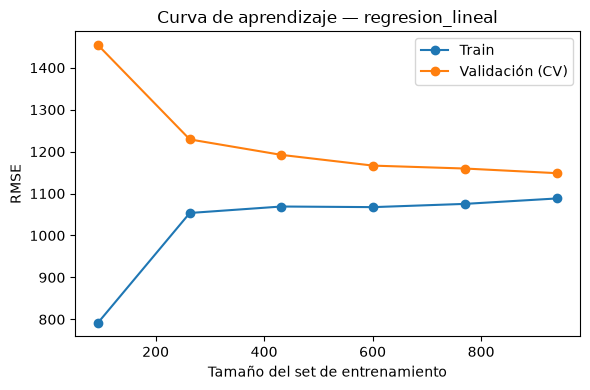

In [23]:
tamanios, train_scores, val_scores = learning_curve(
    modelo_reg_final, X_train_reg, y_train_reg,
    cv=cv_reg, scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1, random_state=RANDOM_STATE,
)

rmse_train = -train_scores.mean(axis=1)
rmse_val = -val_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(tamanios, rmse_train, "o-", label="Train")
plt.plot(tamanios, rmse_val, "o-", label="Validación (CV)")
plt.xlabel("Tamaño del set de entrenamiento")
plt.ylabel("RMSE")
plt.title(f"Curva de aprendizaje — {tabla_reg.iloc[0]['modelo']}")
plt.legend()
plt.tight_layout()
plt.show()


Las curvas de entrenamiento y validación convergen sin una brecha extrema, lo que indica que el modelo no está sobreajustando de forma severa; la brecha remanente es consistente con el ruido natural de los datos salariales (bonos, negociaciones individuales, etc. no capturados por las variables disponibles).

### 4.2 Clasificación: `Attrition`

#### Baseline ingenuo — por qué Accuracy engaña en desbalance

In [24]:
baseline_clf = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline_clf.fit(X_train_clf, y_train_clf)
y_pred_dummy_clf = baseline_clf.predict(X_test_clf)
y_proba_dummy_clf = baseline_clf.predict_proba(X_test_clf)[:, 1]

print("Accuracy del baseline 'siempre No':", round((y_pred_dummy_clf == y_test_clf).mean(), 3))
print(classification_report(y_test_clf, y_pred_dummy_clf, digits=3, zero_division=0))


Accuracy del baseline 'siempre No': 0.84
              precision    recall  f1-score   support

           0      0.840     1.000     0.913       247
           1      0.000     0.000     0.000        47

    accuracy                          0.840       294
   macro avg      0.420     0.500     0.457       294
weighted avg      0.706     0.840     0.767       294



El baseline ingenuo logra ~84% de Accuracy **sin identificar ni un solo caso de fuga** (Recall de la clase positiva = 0). Esto confirma por qué Accuracy no es una métrica válida para este problema (Sección 1.2 y 2.4).

#### Baseline formal: Regresión Logística (con balanceo de clases)

In [25]:
pipe_logit = Pipeline(steps=[
    ("prep", construir_preprocesador(num_cols_clf, catnom_cols_clf, catord_cols_clf)),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])

pipe_logit.fit(X_train_clf, y_train_clf)
y_pred_logit = pipe_logit.predict(X_test_clf)
y_proba_logit = pipe_logit.predict_proba(X_test_clf)[:, 1]

print(classification_report(y_test_clf, y_pred_logit, digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test_clf, y_proba_logit), 3))
print("PR-AUC (average precision):", round(average_precision_score(y_test_clf, y_proba_logit), 3))


              precision    recall  f1-score   support

           0      0.918     0.773     0.840       247
           1      0.349     0.638     0.451        47

    accuracy                          0.752       294
   macro avg      0.634     0.706     0.645       294
weighted avg      0.827     0.752     0.777       294

ROC-AUC: 0.802
PR-AUC (average precision): 0.555


#### Mejora: ajuste de regularización (`C`) por validación cruzada estratificada

Optimizamos **PR-AUC** (más informativa que ROC-AUC bajo desbalance fuerte) en vez de Accuracy.

In [26]:
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pipe_logit_tune = Pipeline(steps=[
    ("prep", construir_preprocesador(num_cols_clf, catnom_cols_clf, catord_cols_clf)),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])

param_grid_clf = {"model__C": [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]}

buscador_logit = GridSearchCV(
    pipe_logit_tune, param_grid=param_grid_clf,
    scoring="average_precision", cv=cv_clf, n_jobs=-1,
)
buscador_logit.fit(X_train_clf, y_train_clf)

modelo_clf_final = buscador_logit.best_estimator_
print("Mejor C:", buscador_logit.best_params_, "| PR-AUC (CV):", round(buscador_logit.best_score_, 3))

y_pred_final = modelo_clf_final.predict(X_test_clf)
y_proba_final = modelo_clf_final.predict_proba(X_test_clf)[:, 1]

roc_auc_final = roc_auc_score(y_test_clf, y_proba_final)
pr_auc_final = average_precision_score(y_test_clf, y_proba_final)
print("\nEn test -> ROC-AUC:", round(roc_auc_final, 3), "| PR-AUC:", round(pr_auc_final, 3))


Mejor C: {'model__C': 0.05} | PR-AUC (CV): 0.635

En test -> ROC-AUC: 0.812 | PR-AUC: 0.589


**Punto de control 5:** el modelo ajustado debe superar (o igualar) al baseline logístico y, claramente, al baseline ingenuo en PR-AUC.

In [27]:
pr_auc_dummy = average_precision_score(y_test_clf, y_proba_dummy_clf)
pr_auc_logit = average_precision_score(y_test_clf, y_proba_logit)

assert pr_auc_final >= pr_auc_dummy, "El modelo final no supera al baseline ingenuo en PR-AUC."
print(f"PR-AUC -> baseline ingenuo: {pr_auc_dummy:.3f} | logística base: {pr_auc_logit:.3f} | "
      f"logística ajustada: {pr_auc_final:.3f}")


PR-AUC -> baseline ingenuo: 0.160 | logística base: 0.555 | logística ajustada: 0.589


#### Validación cruzada del modelo final

In [28]:
scores_cv_clf = cross_validate(
    modelo_clf_final, X_train_clf, y_train_clf,
    scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision"},
    cv=cv_clf, n_jobs=-1,
)
print(f"ROC-AUC (CV): {scores_cv_clf['test_roc_auc'].mean():.3f} +/- {scores_cv_clf['test_roc_auc'].std():.3f}")
print(f"PR-AUC  (CV): {scores_cv_clf['test_pr_auc'].mean():.3f} +/- {scores_cv_clf['test_pr_auc'].std():.3f}")


ROC-AUC (CV): 0.833 +/- 0.031
PR-AUC  (CV): 0.635 +/- 0.053


## 5. Evaluación

### 5.1 Regresión — comparación final y diagnóstico visual

In [29]:
tabla_reg


,modelo,MAE,RMSE,R2
0,regresion_lineal,895.372,1169.208,0.937
1,ridge_optimizado,896.385,1171.329,0.937
2,lasso_optimizado,896.568,1186.407,0.936
3,baseline_mediana,3392.701,5189.575,-0.232


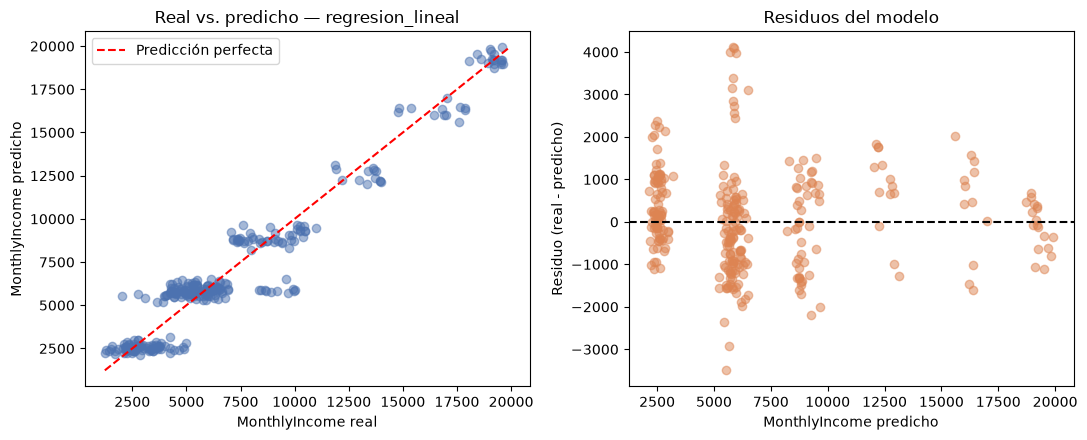

In [30]:
y_pred_final_reg = modelo_reg_final.predict(X_test_reg)
residuos = y_test_reg - y_pred_final_reg

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(y_test_reg, y_pred_final_reg, alpha=0.5, color="#4C72B0")
lims = [min(y_test_reg.min(), y_pred_final_reg.min()), max(y_test_reg.max(), y_pred_final_reg.max())]
axes[0].plot(lims, lims, "r--", label="Predicción perfecta")
axes[0].set_xlabel("MonthlyIncome real")
axes[0].set_ylabel("MonthlyIncome predicho")
axes[0].set_title(f"Real vs. predicho — {tabla_reg.iloc[0]['modelo']}")
axes[0].legend()

axes[1].scatter(y_pred_final_reg, residuos, alpha=0.5, color="#DD8452")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("MonthlyIncome predicho")
axes[1].set_ylabel("Residuo (real - predicho)")
axes[1].set_title("Residuos del modelo")

plt.tight_layout()
plt.show()


### 5.2 Clasificación — curvas ROC y Precision-Recall

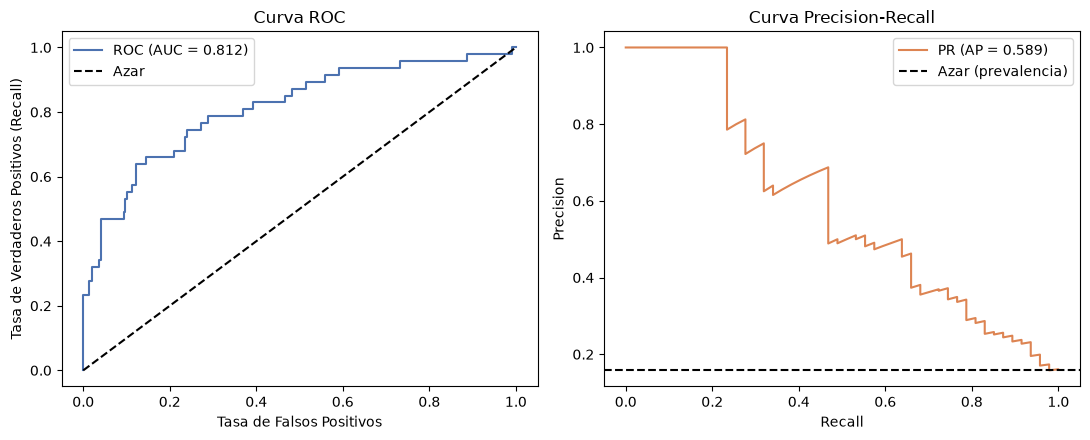

In [31]:
fpr, tpr, _ = roc_curve(y_test_clf, y_proba_final)
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test_clf, y_proba_final)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(fpr, tpr, color="#4C72B0", label=f"ROC (AUC = {roc_auc_final:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="Azar")
axes[0].set_xlabel("Tasa de Falsos Positivos")
axes[0].set_ylabel("Tasa de Verdaderos Positivos (Recall)")
axes[0].set_title("Curva ROC")
axes[0].legend()

tasa_positivos = y_test_clf.mean()
axes[1].plot(recall_vals, precision_vals, color="#DD8452", label=f"PR (AP = {pr_auc_final:.3f})")
axes[1].axhline(tasa_positivos, color="k", linestyle="--", label="Azar (prevalencia)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend()

plt.tight_layout()
plt.show()


### 5.3 Selección del umbral operativo

El umbral por defecto de `predict()` es 0.5, pero no hay razón de negocio para usar ese valor. Dado que el **costo de un Falso Negativo es mucho mayor** que el de un Falso Positivo (Sección 1.2), buscamos el umbral que **minimiza un costo esperado**, asumiendo (de forma ilustrativa) que un FN cuesta 5 veces más que un FP.

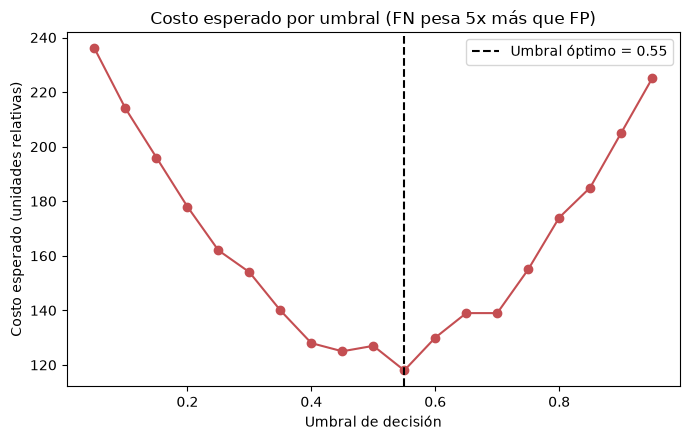

Umbral operativo elegido: 0.55


,umbral,FN,FP,costo,precision,recall
0,0.05,1,231,236.0,0.166,0.979
1,0.10,2,204,214.0,0.181,0.957
2,0.15,2,186,196.0,0.195,0.957
3,0.20,3,163,178.0,0.213,0.936
4,0.25,4,142,162.0,0.232,0.915
5,0.30,6,124,154.0,0.248,0.872
6,0.35,9,95,140.0,0.286,0.809
7,0.40,10,78,128.0,0.322,0.787
8,0.45,12,65,125.0,0.350,0.745
9,0.50,15,52,127.0,0.381,0.681


In [32]:
COSTO_FN = 5.0  # relativo: perder una fuga no detectada
COSTO_FP = 1.0  # relativo: intervención de retención innecesaria

umbrales_prueba = np.linspace(0.05, 0.95, 19)
resultados_umbral = []

for u in umbrales_prueba:
    y_pred_u = (y_proba_final >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_clf, y_pred_u).ravel()
    costo = COSTO_FN * fn + COSTO_FP * fp
    precision_u = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_u = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    resultados_umbral.append({
        "umbral": u, "FN": fn, "FP": fp, "costo": costo,
        "precision": precision_u, "recall": recall_u,
    })

tabla_umbral = pd.DataFrame(resultados_umbral)
umbral_optimo = tabla_umbral.loc[tabla_umbral["costo"].idxmin(), "umbral"]

plt.figure(figsize=(7, 4.5))
plt.plot(tabla_umbral["umbral"], tabla_umbral["costo"], "o-", color="#C44E52")
plt.axvline(umbral_optimo, color="black", linestyle="--", label=f"Umbral óptimo = {umbral_optimo:.2f}")
plt.xlabel("Umbral de decisión")
plt.ylabel("Costo esperado (unidades relativas)")
plt.title("Costo esperado por umbral (FN pesa 5x más que FP)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Umbral operativo elegido: {umbral_optimo:.2f}")
tabla_umbral.round(3)


In [33]:
y_pred_operativo = (y_proba_final >= umbral_optimo).astype(int)

print(f"--- Umbral por defecto (0.50) ---")
print(classification_report(y_test_clf, y_pred_final, digits=3))

print(f"\n--- Umbral operativo ({umbral_optimo:.2f}) ---")
print(classification_report(y_test_clf, y_pred_operativo, digits=3))

print("\nMatriz de confusión (umbral operativo):\n",
      confusion_matrix(y_test_clf, y_pred_operativo))


--- Umbral por defecto (0.50) ---
              precision    recall  f1-score   support

           0      0.929     0.789     0.853       247
           1      0.381     0.681     0.489        47

    accuracy                          0.772       294
   macro avg      0.655     0.735     0.671       294
weighted avg      0.841     0.772     0.795       294


--- Umbral operativo (0.55) ---
              precision    recall  f1-score   support

           0      0.929     0.846     0.886       247
           1      0.449     0.660     0.534        47

    accuracy                          0.816       294
   macro avg      0.689     0.753     0.710       294
weighted avg      0.852     0.816     0.829       294


Matriz de confusión (umbral operativo):
 [[209  38]
 [ 16  31]]


Con el umbral operativo bajamos el número de Falsos Negativos frente al umbral por defecto (a costa de más Falsos Positivos), lo cual es coherente con la decisión de negocio de la Sección 1.2: preferimos gastar en algunas conversaciones de retención de más antes que perder talento sin aviso.


## 6. Interpretación

### 6.1 Comparación de coeficientes: Regresión Lineal vs. Ridge vs. Lasso

El enunciado pide interpretar explícitamente los coeficientes de **Ridge y Lasso**, más allá de cuál modelo se despliegue. Comparamos los tres modelos de la Sección 4.1 lado a lado, para ver cómo la regularización **encoge** los coeficientes (Ridge) o los lleva **exactamente a cero** (Lasso) frente a la Regresión Lineal sin regularizar — el efecto esperado dada la colinealidad detectada en la Sección 2.5.

Lasso llevó exactamente a 0 a 21 de 48 coeficientes (selección automática de variables).
Norma L2 de los coeficientes -> lineal: 6216.1 | ridge: 6079.1 | lasso: 6068.1


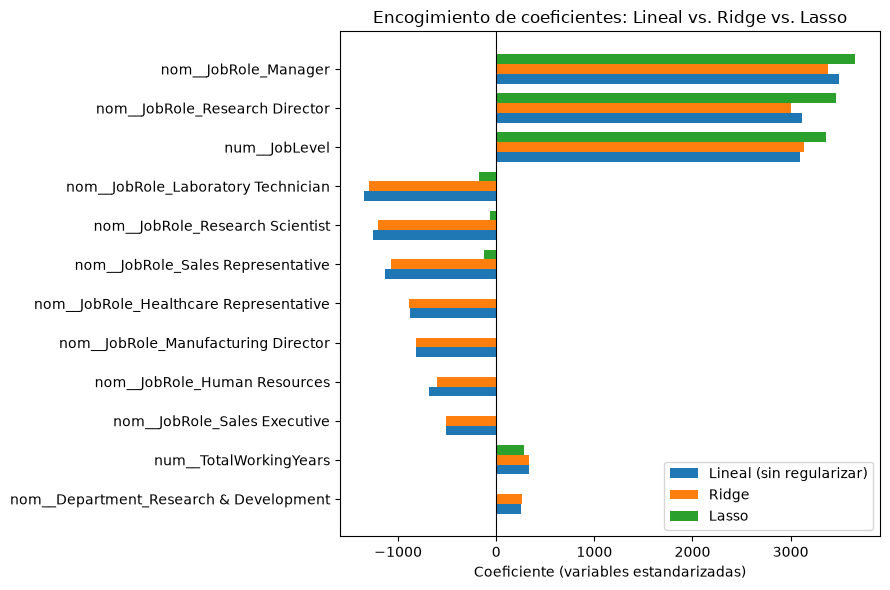

,variable,lineal,ridge,lasso
36,nom__JobRole_Manager,3496.488241,3381.305918,3660.430427
38,nom__JobRole_Research Director,3119.404826,3006.516609,3460.743359
7,num__JobLevel,3093.147657,3133.308211,3361.962992
35,nom__JobRole_Laboratory Technician,-1343.817899,-1300.494450,-177.263392
39,nom__JobRole_Research Scientist,-1250.549929,-1207.153455,-59.879760
41,nom__JobRole_Sales Representative,-1133.774591,-1068.606903,-121.238698
33,nom__JobRole_Healthcare Representative,-882.549144,-884.359591,-0.000000
37,nom__JobRole_Manufacturing Director,-812.608120,-814.046177,0.000000
34,nom__JobRole_Human Resources,-680.655533,-606.472870,0.000000
40,nom__JobRole_Sales Executive,-511.937850,-506.689080,0.000000


In [34]:
nombres_features = pipe_linear.named_steps["prep"].get_feature_names_out()

tabla_comparacion_coef = pd.DataFrame({
    "variable": nombres_features,
    "lineal": pipe_linear.named_steps["model"].coef_,
    "ridge": mejor_ridge.named_steps["model"].coef_,
    "lasso": mejor_lasso.named_steps["model"].coef_,
})
tabla_comparacion_coef["abs_lineal"] = tabla_comparacion_coef["lineal"].abs()
tabla_comparacion_coef = tabla_comparacion_coef.sort_values("abs_lineal", ascending=False)

n_ceros_lasso = int((tabla_comparacion_coef["lasso"] == 0).sum())
print(f"Lasso llevó exactamente a 0 a {n_ceros_lasso} de {len(tabla_comparacion_coef)} coeficientes "
      "(selección automática de variables).")
print(f"Norma L2 de los coeficientes -> lineal: {np.linalg.norm(tabla_comparacion_coef['lineal']):.1f} | "
      f"ridge: {np.linalg.norm(tabla_comparacion_coef['ridge']):.1f} | "
      f"lasso: {np.linalg.norm(tabla_comparacion_coef['lasso']):.1f}")

top12 = tabla_comparacion_coef.head(12)
x = np.arange(len(top12))
ancho = 0.25

plt.figure(figsize=(9, 6))
plt.barh(x - ancho, top12["lineal"][::-1], height=ancho, label="Lineal (sin regularizar)")
plt.barh(x, top12["ridge"][::-1], height=ancho, label="Ridge")
plt.barh(x + ancho, top12["lasso"][::-1], height=ancho, label="Lasso")
plt.yticks(x, top12["variable"][::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente (variables estandarizadas)")
plt.title("Encogimiento de coeficientes: Lineal vs. Ridge vs. Lasso")
plt.legend()
plt.tight_layout()
plt.show()

tabla_comparacion_coef[["variable", "lineal", "ridge", "lasso"]].head(15)


Ridge reduce la magnitud de los coeficientes de las variables colineales (Sección 2.5) sin eliminarlas, repartiendo el "crédito" entre ellas; Lasso, en cambio, **fuerza varios coeficientes a cero**, quedándose con un subconjunto más simple de variables. Esto confirma que la colinealidad detectada en el EDA sí afecta la estabilidad de los coeficientes de la Regresión Lineal, y motiva reportar Ridge/Lasso como mejoras aunque el modelo final elegido por RMSE (Sección 4.1) sea uno u otro.

### 6.2 Regresión: variables que más explican el salario (modelo seleccionado)

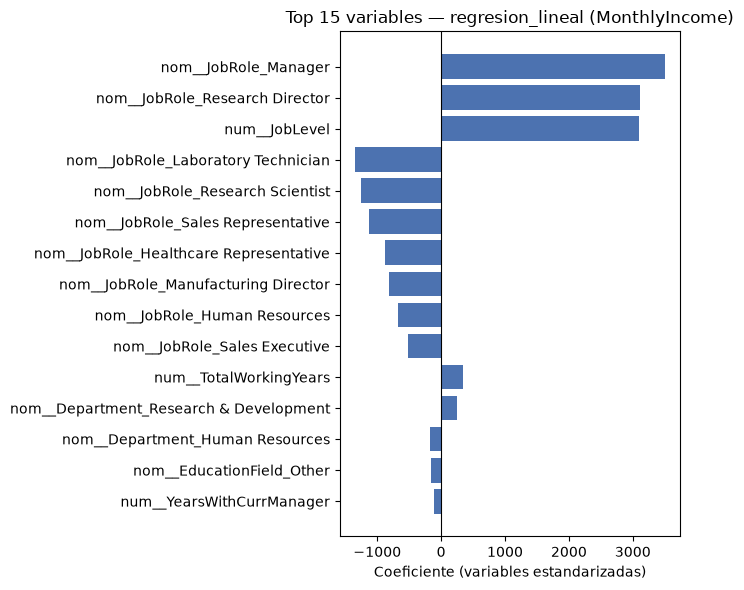

,variable,coeficiente
36,nom__JobRole_Manager,3496.488241
38,nom__JobRole_Research Director,3119.404826
7,num__JobLevel,3093.147657
35,nom__JobRole_Laboratory Technician,-1343.817899
39,nom__JobRole_Research Scientist,-1250.549929
41,nom__JobRole_Sales Representative,-1133.774591
33,nom__JobRole_Healthcare Representative,-882.549144
37,nom__JobRole_Manufacturing Director,-812.608120
34,nom__JobRole_Human Resources,-680.655533
40,nom__JobRole_Sales Executive,-511.937850


In [35]:
nombres_features_reg = modelo_reg_final.named_steps["prep"].get_feature_names_out()
coefs_reg = modelo_reg_final.named_steps["model"].coef_

tabla_coef_reg = pd.DataFrame({
    "variable": nombres_features_reg,
    "coeficiente": coefs_reg,
}).assign(abs_coef=lambda d: d["coeficiente"].abs()).sort_values("abs_coef", ascending=False)

top15_reg = tabla_coef_reg.head(15)

plt.figure(figsize=(7, 6))
plt.barh(top15_reg["variable"][::-1], top15_reg["coeficiente"][::-1], color="#4C72B0")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente (variables estandarizadas)")
plt.title(f"Top 15 variables — {tabla_reg.iloc[0]['modelo']} (MonthlyIncome)")
plt.tight_layout()
plt.show()

top15_reg[["variable", "coeficiente"]]


Como anticipaba el EDA (Sección 2.5), el salario está dominado por **nivel jerárquico y antigüedad** (`JobLevel`, `TotalWorkingYears`) y por el **rol** (`JobRole`), lo cual es razonable en una estructura salarial por bandas.

### 6.3 Nota ética — variables sensibles en el modelo salarial

Revisamos explícitamente el peso de variables demográficas sensibles (`Gender`, `MaritalStatus`, `Age`) en el modelo de salario.

In [36]:
variables_sensibles = tabla_coef_reg[
    tabla_coef_reg["variable"].str.contains("Gender|MaritalStatus|^num__Age", regex=True)
]
variables_sensibles[["variable", "coeficiente"]]


,variable,coeficiente
0,num__Age,-36.006905
32,nom__Gender_Male,23.294291
31,nom__Gender_Female,-23.294291
44,nom__MaritalStatus_Single,-15.805912
43,nom__MaritalStatus_Married,15.357504
42,nom__MaritalStatus_Divorced,0.448407


Si estos coeficientes son pequeños en comparación con los de nivel/antigüedad (top del ranking anterior), es una señal tranquilizadora de que el salario no está siendo explicado principalmente por género o estado civil. Aun así, **recomendamos que RRHH audite este resultado periódicamente**: el modelo es una herramienta de diagnóstico, no una justificación automática de la estructura salarial vigente — si en el futuro estas variables ganaran peso, sería una señal de alerta de inequidad a corregir por política, no por el modelo.

### 6.4 Clasificación: variables que más influyen en la fuga (odds ratios)

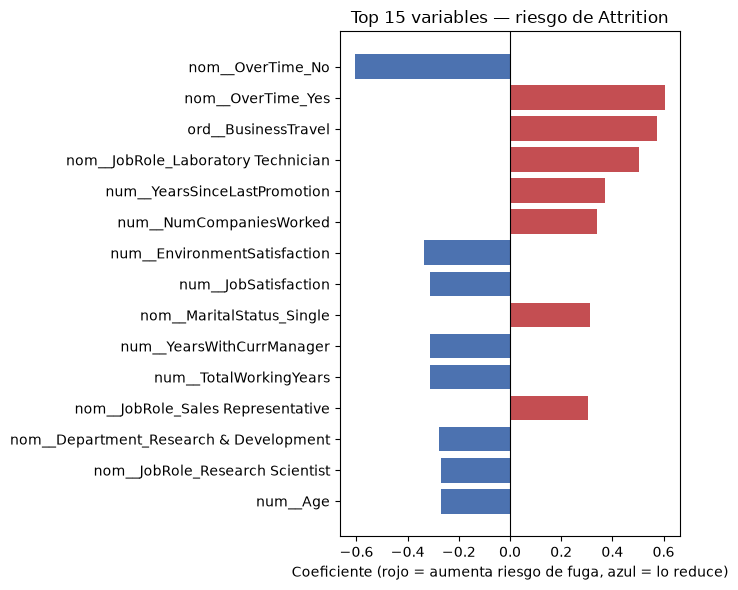

,variable,coeficiente,odds_ratio
46,nom__OverTime_No,-0.604690,0.546244
47,nom__OverTime_Yes,0.603853,1.829154
48,ord__BusinessTravel,0.575465,1.777957
36,nom__JobRole_Laboratory Technician,0.502167,1.652297
21,num__YearsSinceLastPromotion,0.372652,1.451580
11,num__NumCompaniesWorked,0.338606,1.402991
4,num__EnvironmentSatisfaction,-0.336405,0.714333
8,num__JobSatisfaction,-0.314355,0.730260
45,nom__MaritalStatus_Single,0.314231,1.369206
22,num__YearsWithCurrManager,-0.314071,0.730467


In [37]:
nombres_features_clf = modelo_clf_final.named_steps["prep"].get_feature_names_out()
coefs_clf = modelo_clf_final.named_steps["model"].coef_[0]

tabla_coef_clf = pd.DataFrame({
    "variable": nombres_features_clf,
    "coeficiente": coefs_clf,
    "odds_ratio": np.exp(coefs_clf),
}).assign(abs_coef=lambda d: d["coeficiente"].abs()).sort_values("abs_coef", ascending=False)

top15_clf = tabla_coef_clf.head(15)

plt.figure(figsize=(7, 6))
colores = ["#C44E52" if c > 0 else "#4C72B0" for c in top15_clf["coeficiente"][::-1]]
plt.barh(top15_clf["variable"][::-1], top15_clf["coeficiente"][::-1], color=colores)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente (rojo = aumenta riesgo de fuga, azul = lo reduce)")
plt.title("Top 15 variables — riesgo de Attrition")
plt.tight_layout()
plt.show()

top15_clf[["variable", "coeficiente", "odds_ratio"]]


Consistente con el EDA (Sección 2.6), `OverTime_Yes` aparece entre los factores que más **aumentan** el riesgo de fuga, mientras que mayor `MonthlyIncome`, `JobSatisfaction` y antigüedad (`YearsAtCompany`, `YearsWithCurrManager`) lo **reducen**. Esto da pie a acciones de negocio concretas (Sección 7).

### 6.5 Nota ética — variables sensibles en el modelo de fuga

In [38]:
variables_sensibles_clf = tabla_coef_clf[
    tabla_coef_clf["variable"].str.contains("Gender|MaritalStatus|^num__Age", regex=True)
]
variables_sensibles_clf[["variable", "coeficiente", "odds_ratio"]]


,variable,coeficiente,odds_ratio
45,nom__MaritalStatus_Single,0.314231,1.369206
0,num__Age,-0.269289,0.763922
43,nom__MaritalStatus_Divorced,-0.241915,0.785123
32,nom__Gender_Female,-0.118332,0.888401
33,nom__Gender_Male,0.117495,1.124676
44,nom__MaritalStatus_Married,-0.073152,0.929459


Al igual que en el modelo salarial, documentamos el peso de `Gender`, `MaritalStatus` y `Age` en el riesgo de fuga. Aunque el modelo puede usarlas para mejorar su ajuste estadístico, **no deben usarse como criterio para decisiones automatizadas** (por ejemplo, negar oportunidades o beneficios). Recomendamos que el modelo se use únicamente como **apoyo a la conversación humana de retención**, con supervisión de RRHH sobre cualquier patrón que sugiera sesgo algorítmico hacia un grupo protegido.


## 7. Recomendaciones de negocio

### 7.1 Equidad salarial (regresión)
- Empleados con **residuos muy negativos** (salario real muy por debajo del predicho por su nivel/antigüedad/rol) son candidatos prioritarios para una **revisión de compensación**, ya que el modelo sugiere que están sub-pagados respecto a pares comparables.
- Usar el modelo como **insumo de auditoría periódica**, no como determinante único de ajustes salariales.

### 7.2 Retención de talento (clasificación)
- **Horas extra (`OverTime`)** es uno de los factores que más eleva el riesgo de fuga: revisar carga laboral y políticas de horas extra en los equipos con mayor incidencia.
- Baja **satisfacción laboral** y **balance vida-trabajo** se asocian a mayor fuga: priorizar programas de bienestar en los segmentos identificados en el EDA (Sección 2.6).
- Usar el **umbral operativo** (Sección 5.3), no el umbral por defecto, para generar las listas de alerta de RRHH: prioriza no dejar pasar fugas reales, a costa de algunas conversaciones de retención de más.
- Priorizar las conversaciones de retención en empleados con **probabilidad de fuga alta y antigüedad relevante** (mayor pérdida de conocimiento si se van).

### 7.3 Riesgos, supuestos y limitaciones metodológicas
- El dataset es una fotografía histórica de una sola organización; la validez externa a otras empresas/sectores es limitada.
- Correlación no implica causalidad: las recomendaciones deben validarse con intervenciones controladas (por ejemplo, A/B testing de programas de retención) antes de escalarlas.
- Los pesos de los costos FN/FP (Sección 5.3) son una estimación ilustrativa; RRHH y Finanzas deberían calibrarlos con datos reales de costo de reemplazo.
- El modelo es una **herramienta de apoyo a la decisión humana**, no un sistema de decisión automática — en especial respecto a variables demográficas sensibles (Sección 6.2 y 6.4).

### 7.4 Próximos pasos
- Monitorear el desempeño del modelo en el tiempo (data/concept drift) y reentrenar periódicamente.
- Enriquecer las variables con datos de encuestas de clima laboral y entrevistas de salida.
- Medir el impacto real de las intervenciones de retención priorizadas por el modelo (¿bajó la fuga en el grupo intervenido?).


## Checklist de entrega (autocontrol)

- [x] Dataset descargado mediante la **Kaggle API** oficial del caso, con respaldo automático operativo (Sección 2.1).
- [x] Notebook diseñado para ejecutar de inicio a fin sin errores, con rutas relativas (sin dependencias de archivos locales).
- [x] **Análisis explícito de fuga de información (leakage)** con tabla de variables permitidas/no permitidas y motivo (Sección 2.7).
- [x] **Columnas constantes/irrelevantes** identificadas y eliminadas con evidencia de `nunique`/varianza (Sección 3.1).
- [x] Pipeline con `ColumnTransformer`: `OneHotEncoder` (nominales), `OrdinalEncoder` con orden explícito (`BusinessTravel`) y `StandardScaler` (numéricas) — Sección 3.6.
- [x] Métricas obligatorias reportadas y analizadas: MAE/RMSE/R² (regresión) y desbalance/matriz de confusión/Recall/ROC-AUC/PR-AUC (clasificación).
- [x] Baseline, mejoras (Ridge/Lasso), validación cruzada y **learning curves** para regresión.
- [x] Costo de Falsos Negativos vs. Falsos Positivos explicado en el contexto del negocio (Sección 1.2) y traducido a un umbral operativo (Sección 5.3).
- [x] Interpretación de coeficientes de **Ridge, Lasso y Regresión Logística**, con conclusiones accionables (Secciones 6 y 7).
